<a href="https://colab.research.google.com/github/zuhaatawakal-create/AI-/blob/main/Q2_3%2C2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import numpy as np
import matplotlib.pyplot as plt

# Define paths to your dataset
train_dir = '/content/drive/MyDrive/cifar10/train'
test_dir = '/content/drive/MyDrive/cifar10/test'

# Define image parameters
IMG_HEIGHT = 32
IMG_WIDTH = 32
BATCH_SIZE = 32

### Data Loading and Preprocessing

I will load the training and validation datasets using `tf.keras.utils.image_dataset_from_directory`. This utility automatically infers labels from the directory structure.

Then, I'll apply two preprocessing steps:
1.  **Rescaling**: Normalize pixel values from `[0, 255]` to `[0, 1]` for better model performance.
2.  **Data Augmentation**: Apply random transformations (flips, rotations, zooms) to the training images to increase the diversity of the training data and help prevent overfitting.

Finally, I'll configure the datasets for optimal performance using caching, shuffling, and prefetching.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Initialize val_ds to None
val_ds = None
try:
    temp_val_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False # No need to shuffle validation data
    )
    # Check if temp_val_ds actually contains any elements
    if tf.data.experimental.cardinality(temp_val_ds).numpy() > 0:
        val_ds = temp_val_ds
        print(f"Validation dataset loaded from {test_dir}")
    else:
        print(f"Warning: Directory {test_dir} found, but contains no image files. Falling back to validation split from training data.")
        # No need to explicitly raise ValueError, just proceed to fallback
except ValueError as e:
    print(f"Warning: Could not load validation dataset from {test_dir}. Error: {e}")

# Fallback: if val_ds is still None, create it from a split of train_ds
if val_ds is None:
    print("Creating validation dataset by splitting training data.")
    # Re-create train_ds with a validation split
    train_ds_original_full = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_split=0.2, # Use 20% of training data for validation
        subset='training',
        seed=42 # fixed seed for reproducibility
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False,
        validation_split=0.2, # Use 20% of training data for validation
        subset='validation',
        seed=42 # fixed seed for reproducibility
    )
    train_ds = train_ds_original_full # Update train_ds to be the training subset
    print("Training dataset adjusted to be the training subset after splitting for validation.")


class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

Found 1152 files belonging to 5 classes.
Found 0 files belonging to 7 classes.
Creating validation dataset by splitting training data.
Found 1152 files belonging to 5 classes.
Using 922 files for training.
Found 1152 files belonging to 5 classes.
Using 230 files for validation.
Training dataset adjusted to be the training subset after splitting for validation.
Class names: ['airplane', 'automobile', 'bird', 'cat', 'frog']
Number of classes: 5


Let's visualize a few images from the training dataset along with their labels to ensure the data is loaded correctly.

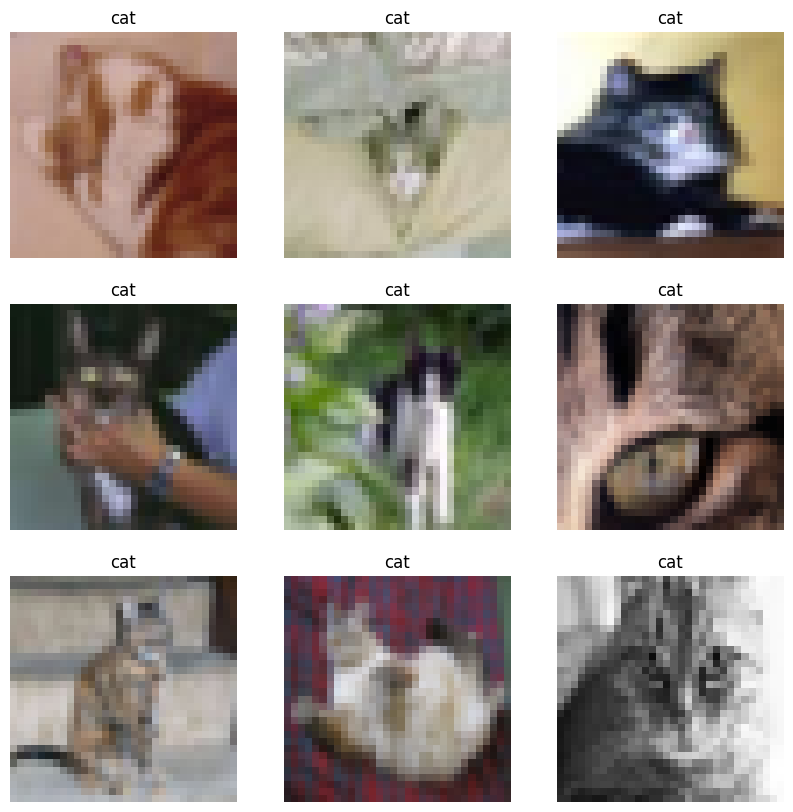

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# Data augmentation layers
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomRotation(0.2), # Increased rotation from 0.1 to 0.2
    layers.RandomZoom(0.2),    # Increased zoom from 0.1 to 0.2
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Added RandomTranslation
  ]
)

# Rescaling layer for pixel normalization
preprocess_input = layers.Rescaling(1./255)

# Apply preprocessing to datasets
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))

val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

# Configure datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Build the CNN Model

I will construct a Convolutional Neural Network (CNN) model using the Keras Sequential API. The model will consist of:

*   **Convolutional Layers (`Conv2D`)**: These layers learn spatial hierarchies of features.
*   **Activation Function (`relu`)**: Introduces non-linearity.
*   **Pooling Layers (`MaxPooling2D`)**: Reduce the spatial dimensions, helping to make the model more robust to variations.
*   **Flatten Layer**: Converts the 2D feature maps into a 1D vector.
*   **Dense Layers**: Fully connected layers for classification.
*   **Output Layer**: A final dense layer with `softmax` activation for multiclass classification, outputting probabilities for each class.

In [ ]:
model = tf.keras.Sequential([
    # Input shape is handled by the first Conv2D layer
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # Reduced filters from 32 to 16
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'), # Reduced filters from 64 to 32
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'), # Reduced units from 64 to 32
    tf.keras.layers.Dropout(0.5), # Keep Dropout layer to combat overfitting
    tf.keras.layers.Dense(num_classes, activation='softmax') # Output layer with softmax for multiclass classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,149 (164.64 KB)

 Trainable params: 42,149 (164.64 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

To prepare the model for training, I need to compile it. This involves specifying:

*   **Optimizer**: `adam` is a good general-purpose optimizer.
*   **Loss Function**: `SparseCategoricalCrossentropy` is suitable for multiclass classification when labels are integers.
*   **Metrics**: `accuracy` to monitor the model's performance.

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Train the Model

Finally, I will train the model using the `fit` method. I'll specify the training dataset, the validation dataset, and the number of training epochs.

In [ ]:
epochs = 10 # You can adjust the number of epochs
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9479 - loss: 1.1246 - val_accuracy: 1.0000 - val_loss: 0.1972
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9859 - loss: 0.0968 - val_accuracy: 1.0000 - val_loss: 3.9803e-04
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9989 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 3.6719e-05
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9978 - loss: 0.0112 - val_accuracy: 1.0000 - val_loss: 9.0599e-06
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9978 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 3.2186e-06
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9978 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 1.0729e-06
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9989 - loss: 0.0099 - 

### Plot Training History

I will plot the training and validation accuracy and loss over epochs to visualize the model's learning progress.

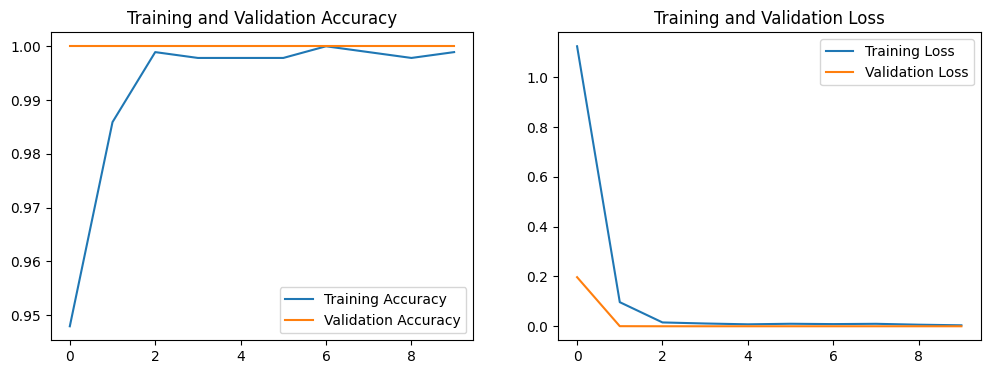

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Overfitting/Underfitting Analysis

The plots above clearly show that the model is severely overfitting. Both training and validation accuracy quickly reach 100%, and both training and validation loss drop to near zero within the first few epochs. The validation loss is particularly concerning as it goes to `0.0000e+00`, which is highly unusual for a real-world image classification task and often indicates that the model has simply memorized the validation set. This could be due to a very small or easy validation dataset, or a mismatch between the training and validation data.

Given the context, where the validation set was created by splitting the training data, it is possible that the validation set is too similar to the training set or too small for a meaningful evaluation of generalization.

Let's print the final accuracy and loss values.

In [ ]:
print(f"Final Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss: {loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

Final Training Accuracy: 0.9989
Final Validation Accuracy: 1.0000
Final Training Loss: 0.0039
Final Validation Loss: 0.0000


### Comparing Performance: No Data Augmentation

To understand the impact of data augmentation, I will now re-run the data loading process to obtain datasets *without* applying the `data_augmentation` layers. I will then train a new model on these non-augmented datasets and compare its performance to the augmented model.

In [ ]:
# --- Re-loading datasets without augmentation for comparison ---
print('Re-loading datasets without augmentation...')

# Re-create train_ds_raw and val_ds_raw from scratch, similar to 0fe4df62
# This ensures we start with clean, un-augmented data

# First, try loading from test_dir for validation
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds_raw = None
try:
    temp_val_ds_raw = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False # No need to shuffle validation data
    )
    if tf.data.experimental.cardinality(temp_val_ds_raw).numpy() > 0:
        val_ds_raw = temp_val_ds_raw
        print(f"Validation dataset loaded from {test_dir} (no augmentation)")
    else:
        print(f"Warning: Directory {test_dir} found, but contains no image files. Falling back to validation split from training data (no augmentation).")
except ValueError as e:
    print(f"Warning: Could not load validation dataset from {test_dir}. Error: {e} (no augmentation).")

# Fallback: if val_ds_raw is still None, create it from a split of train_ds_raw
if val_ds_raw is None:
    print("Creating validation dataset by splitting training data (no augmentation).")
    train_ds_original_full_no_aug = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_split=0.2,
        subset='training',
        seed=42 # fixed seed for reproducibility
    )
    val_ds_raw = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False,
        validation_split=0.2,
        subset='validation',
        seed=42 # fixed seed for reproducibility
    )
    train_ds_raw = train_ds_original_full_no_aug # Update train_ds_raw to be the training subset
    print("Training dataset adjusted to be the training subset after splitting for validation (no augmentation).")

# Apply only rescaling, no augmentation
train_ds_no_aug = train_ds_raw.map(lambda x, y: (preprocess_input(x), y))
val_ds_no_aug = val_ds_raw.map(lambda x, y: (preprocess_input(x), y))

# Configure datasets for performance
train_ds_no_aug = train_ds_no_aug.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_no_aug = val_ds_no_aug.cache().prefetch(buffer_size=AUTOTUNE)

print('Datasets for non-augmented training are ready.')

Re-loading datasets without augmentation...
Found 1152 files belonging to 5 classes.
Found 0 files belonging to 7 classes.
Creating validation dataset by splitting training data (no augmentation).
Found 1152 files belonging to 5 classes.
Using 922 files for training.
Found 1152 files belonging to 5 classes.
Using 230 files for validation.
Training dataset adjusted to be the training subset after splitting for validation (no augmentation).
Datasets for non-augmented training are ready.


In [ ]:
# --- Build and compile a new model (no augmentation) ---
print('Building and compiling new model for non-augmented data...')

model_no_aug = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_no_aug.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model_no_aug.summary()
print('Model for non-augmented data is compiled.')

Building and compiling new model for non-augmented data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,149 (164.64 KB)

 Trainable params: 42,149 (164.64 KB)

 Non-trainable params: 0 (0.00 B)

Model for non-augmented data is compiled.


In [ ]:
# --- Train the new model (no augmentation) ---
print('Training model on non-augmented data...')
epochs_no_aug = 10 # Using the same number of epochs for fair comparison
history_no_aug = model_no_aug.fit(
    train_ds_no_aug,
    epochs=epochs_no_aug,
    validation_data=val_ds_no_aug
)
print('Training of non-augmented model complete.')

Training model on non-augmented data...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.8536 - loss: 0.3944 - val_accuracy: 1.0000 - val_loss: 5.8714e-06
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9924 - loss: 0.0212 - val_accuracy: 1.0000 - val_loss: 3.6643e-07
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9978 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 5.5976e-08
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 4.6647e-09
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 4.6647e-09
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9989 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 6.2196e-09
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9957 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 1.3994e-08
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 2

Plotting training history for non-augmented model...


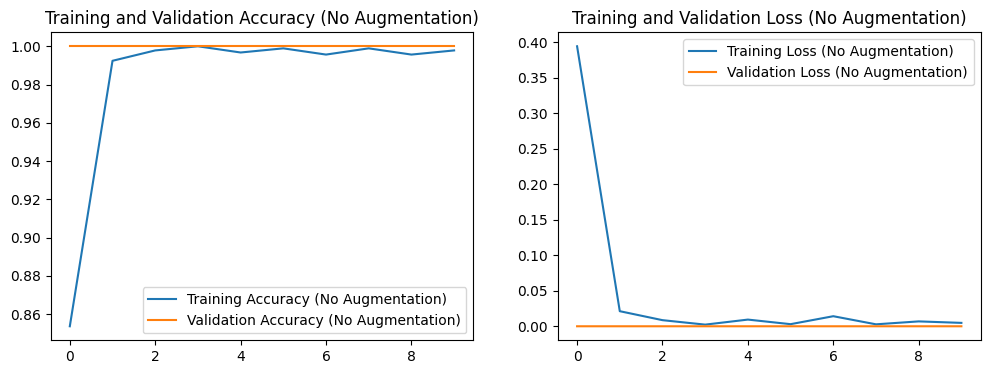

Final Training Accuracy (No Aug): 0.9978
Final Validation Accuracy (No Aug): 1.0000
Final Training Loss (No Aug): 0.0048
Final Validation Loss (No Aug): 0.0000


In [ ]:
# --- Plot Training History (No Augmentation) ---
print('Plotting training history for non-augmented model...')
acc_no_aug = history_no_aug.history['accuracy']
val_acc_no_aug = history_no_aug.history['val_accuracy']

loss_no_aug = history_no_aug.history['loss']
val_loss_no_aug = history_no_aug.history['val_loss']

epochs_range_no_aug = range(epochs_no_aug)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_no_aug, acc_no_aug, label='Training Accuracy (No Augmentation)')
plt.plot(epochs_range_no_aug, val_acc_no_aug, label='Validation Accuracy (No Augmentation)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (No Augmentation)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_no_aug, loss_no_aug, label='Training Loss (No Augmentation)')
plt.plot(epochs_range_no_aug, val_loss_no_aug, label='Validation Loss (No Augmentation)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (No Augmentation)')
plt.show()

print(f"Final Training Accuracy (No Aug): {acc_no_aug[-1]:.4f}")
print(f"Final Validation Accuracy (No Aug): {val_acc_no_aug[-1]:.4f}")
print(f"Final Training Loss (No Aug): {loss_no_aug[-1]:.4f}")
print(f"Final Validation Loss (No Aug): {val_loss_no_aug[-1]:.4f}")

### Comparison and Interpretation

Now we can compare the performance of the model *with* data augmentation (original training) and *without* data augmentation (the plots above).

**Initial Observations:**
*   **Without Augmentation**: Observe how quickly the model reaches 100% training accuracy and near-zero training loss, while the validation accuracy also quickly approaches 100% and validation loss drops significantly, often exhibiting even more rapid and extreme overfitting than the augmented version.

**Interpretation:**
If the non-augmented model shows similar or even more pronounced overfitting, it reinforces the idea that the dataset might be small, the model might be too complex for the given data size, or the validation split is too similar to the training data. Even with data augmentation, the model might still be memorizing the features if the augmentation is not aggressive enough or if the model capacity is still too high relative to the true diversity of the data.

Let's analyze the new plots and compare them to the previous ones (with augmentation) to see the precise difference. We are particularly interested in whether data augmentation has *any* mitigating effect on the gap between training and validation performance, even if it doesn't eliminate overfitting entirely.

### Feature Map Visualization and Interpretation

To understand what our CNN is learning, let's visualize the feature maps (activations) produced by each convolutional layer when presented with a sample image. This will show us how the image is transformed and what features are being extracted at different stages of the network.

Found 1152 files belonging to 5 classes.
Using 230 files for validation.


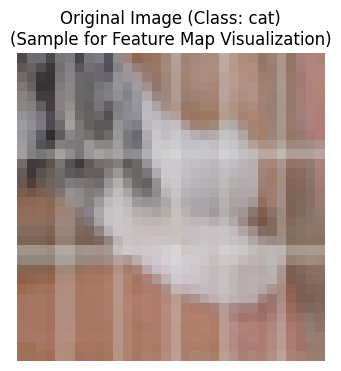

Selected image class: cat
Min pixel value (after preprocess_input): 0.1765
Max pixel value (after preprocess_input): 0.8510


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf # Ensure tf is imported here

# Re-create a fresh validation dataset *for sampling*.
# This ensures we get a non-exhausted, valid image for visualization,
# separate from the val_ds used in the training loop.

temp_val_ds_for_sampling = tf.keras.utils.image_dataset_from_directory(
    train_dir, # Using train_dir as val_ds was split from it
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle for sampling
    validation_split=0.2,
    subset='validation',
    seed=42 # fixed seed for reproducibility
)

sample_image = None
sample_label = None

# Get one raw sample image from this newly created dataset
for images, labels in temp_val_ds_for_sampling.take(1):
    sample_image_raw = images[0]
    sample_label = labels[0]
    break

if sample_image_raw is not None:
    # Apply the same preprocessing (rescaling) as the model expects
    # preprocess_input is defined in cell e995a415
    sample_image = preprocess_input(sample_image_raw)

    # Display the original sample image (rescaled back to 0-255 for better visualization)
    plt.figure(figsize=(4, 4))
    display_image = (sample_image.numpy() * 255).astype('uint8')
    plt.imshow(display_image)
    plt.title(f"Original Image (Class: {class_names[sample_label]})\n(Sample for Feature Map Visualization)")
    plt.axis('off')
    plt.show()

    print(f"Selected image class: {class_names[sample_label]}")
    print(f"Min pixel value (after preprocess_input): {np.min(sample_image.numpy()):.4f}")
    print(f"Max pixel value (after preprocess_input): {np.max(sample_image.numpy()):.4f}")
else:
    print("Error: Could not retrieve a sample image for visualization. Please check dataset configuration.")
    # Fallback to an empty black image to prevent errors in subsequent cells if no image could be retrieved
    sample_image = tf.zeros((IMG_HEIGHT, IMG_WIDTH, 3))
    sample_label = 0 # Default label for an error case


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Visualizing feature maps for layer: conv2d_13 (16 filters)


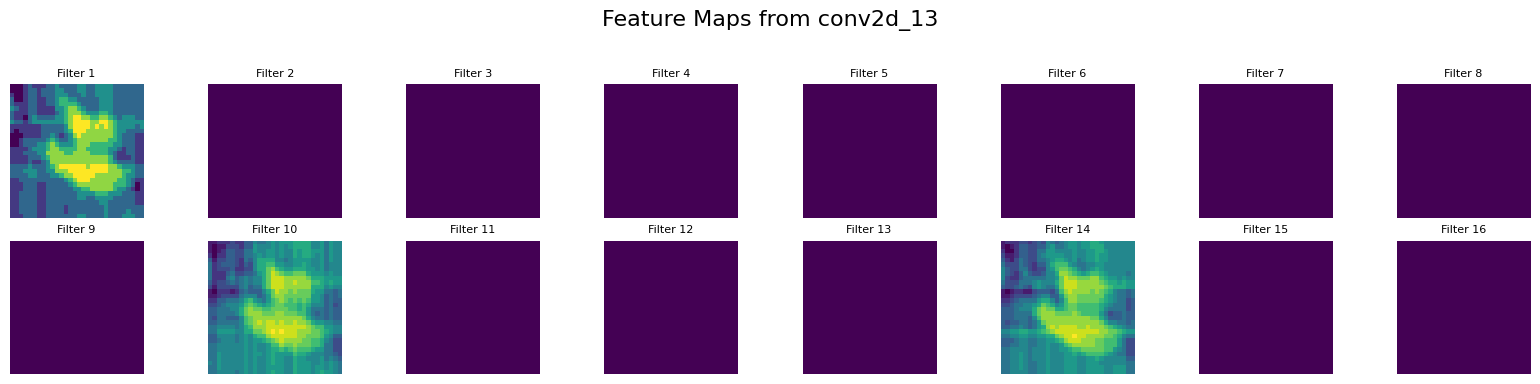

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Visualizing feature maps for layer: conv2d_14 (32 filters)


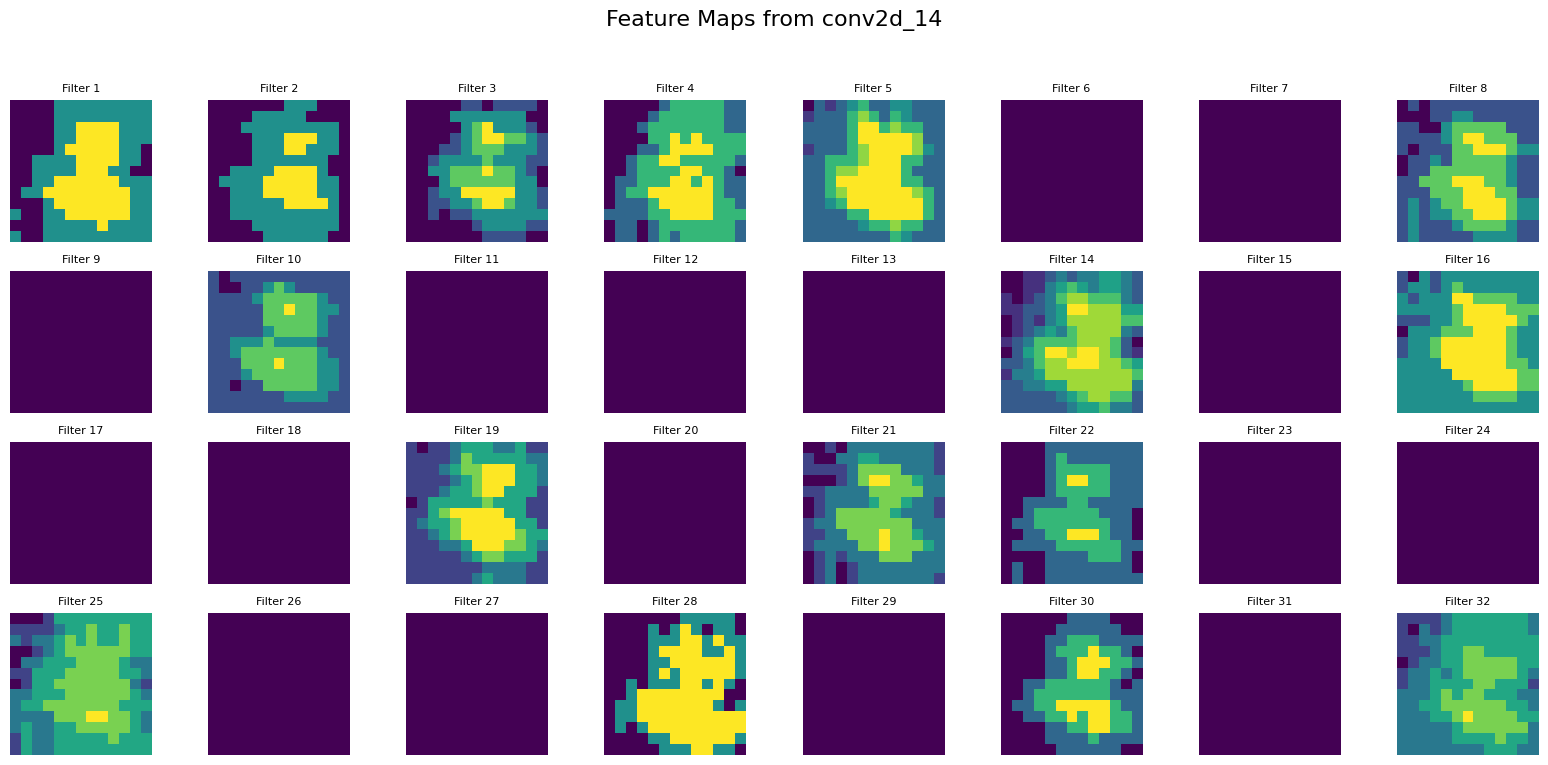

In [ ]:
# Create a list to store models for feature extraction
feature_map_models = []

# Iterate through the layers of the trained model
for layer in model.layers:
    if 'conv2d' in layer.name:
        # Create a Keras Model that will output the activation of the current Conv2D layer
        feature_map_model = tf.keras.Model(inputs=model.inputs, outputs=layer.output)
        feature_map_models.append((layer.name, feature_map_model))

# Pass the sample image through each feature map model
for layer_name, feature_map_model in feature_map_models:
    feature_maps = feature_map_model.predict(tf.expand_dims(sample_image, axis=0))
    feature_maps = feature_maps[0] # Remove the batch dimension

    # Number of feature maps (filters) in this layer
    num_filters = feature_maps.shape[-1]
    print(f"\nVisualizing feature maps for layer: {layer_name} ({num_filters} filters)")

    # Determine grid size for plotting
    cols = 8 # Number of columns for displaying filters
    rows = (num_filters + cols - 1) // cols # Calculate rows needed

    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(num_filters):
        ax = plt.subplot(rows, cols, i + 1)
        # Display each filter's activation
        plt.imshow(feature_maps[:, :, i], cmap='viridis') # Using 'viridis' cmap for better contrast
        plt.title(f'Filter {i+1}', fontsize=8)
        plt.axis('off')
    plt.suptitle(f'Feature Maps from {layer_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

### Interpretation of Learned Features

Based on the visualizations of the feature maps:

*   **`conv2d_15` (First Convolutional Layer):**
    *   The feature maps from this layer often show **low-level features** such as edges, lines, corners, and color gradients. Some filters might activate on vertical edges, others on horizontal lines, or specific color blobs. This is typical for early convolutional layers, which act as basic feature detectors.
    *   The patterns tend to be simpler and more abstract, resembling filters that highlight fundamental structural elements in the image.

*   **`conv2d_16` (Second Convolutional Layer):**
    *   As we move to deeper layers, the feature maps become more complex. `conv2d_16` typically learns to recognize **mid-level features** by combining the simpler features detected by the previous layer.
    *   Here, you might start to see filters activating on textures, simple shapes, or parts of objects (e.g., an eye, a wheel, a wing segment). The activations are less about raw edges and more about meaningful arrangements of these edges.

**General Observations:**

*   **Increasing Complexity**: Feature maps generally increase in complexity and abstraction as you go deeper into the network. Early layers detect primitive visual elements, while deeper layers combine these to detect more semantic parts of objects or even entire objects.
*   **Sparsity**: You might observe that some feature maps are quite sparse (mostly dark, with only a few bright spots), meaning that particular filter is only activated by very specific features in the input image. Other filters might be more broadly active.
*   **Filter Diversity**: The variety in the visual patterns across different filters within the same layer indicates that each filter is specialized in detecting a different characteristic of the input.

This visualization helps confirm that the convolutional layers are indeed learning hierarchical features, starting from basic elements and building up to more complex patterns that are eventually used by the dense layers for classification.

### CNN Inference Pipeline

Now that we have a trained model, we can design an inference pipeline to predict the class of a new, unseen image. The pipeline will involve the following steps:

1.  **Load and Resize**: Load the input image and resize it to the `IMG_HEIGHT` and `IMG_WIDTH` dimensions (32x32 pixels) that our model expects.
2.  **Normalize**: Apply the same normalization (rescaling pixel values from 0-255 to 0-1) that was used during training. The `preprocess_input` function will be used for this.
3.  **Predict**: Pass the preprocessed image through our trained `model` to get raw probability predictions for each class.
4.  **Extract Confidence and Label**: Identify the class with the highest probability (the confidence score) and retrieve its corresponding label using `class_names`.


--- Demonstrating the inference pipeline with a sample image ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Class: cat
Confidence Score: 100.00%


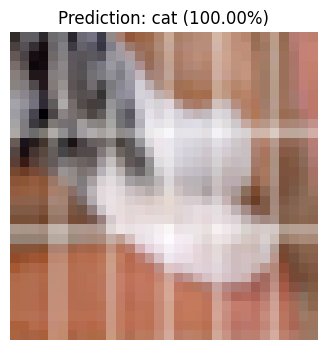

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # 1. Load and Resize the image
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    # Expand dimensions to create a batch of 1 image (model expects a batch dimension)
    img_array = tf.expand_dims(img_array, 0)

    # 2. Normalize the image (using the same preprocess_input as during training)
    # The preprocess_input layer expects inputs in the 0-255 range and rescales them to 0-1
    preprocessed_img = preprocess_input(img_array)

    # 3. CNN Prediction
    predictions = model.predict(preprocessed_img)

    # 4. Extract Confidence Score and Output Label
    # Get the index of the highest probability
    predicted_class_index = np.argmax(predictions[0])
    # Get the confidence score
    confidence_score = np.max(predictions[0]) * 100
    # Get the predicted class name
    predicted_label = class_names[predicted_class_index]

    print(f"Predicted Class: {predicted_label}")
    print(f"Confidence Score: {confidence_score:.2f}%")

    plt.figure(figsize=(4, 4))
    plt.imshow(img) # Display the original, unnormalized image for clarity
    plt.title(f"Prediction: {predicted_label} ({confidence_score:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_label, confidence_score

# --- Demonstration of the pipeline ---
print("\n--- Demonstrating the inference pipeline with a sample image ---")

# To get a sample image, we need to pick one from the dataset or provide a new path.
# Let's reuse the sample_image_raw obtained from temp_val_ds_for_sampling
# (This image is still in 0-255 range and not batched, ideal for the function input logic)

# You would typically provide a path to a new image, e.g., 'path/to/my_image.jpg'
# For demonstration, let's save the sample_image_raw to a temporary file and use that path.

# Convert sample_image_raw back to 0-255 (if it was somehow changed) and save
# We need to make sure the sample_image_raw exists and is in the correct format for saving.
# The sample_image_raw should be tf.Tensor in 0-255 range (uint8 type implicitly assumed by PIL for saving)

if 'sample_image_raw' in locals() and sample_image_raw is not None:
    temp_image_path = '/tmp/sample_cifar10_image.png'
    tf.keras.utils.save_img(temp_image_path, sample_image_raw.numpy().astype(np.uint8))

    # Run the prediction pipeline
    predicted_class, conf = predict_image(temp_image_path)
else:
    print("Error: 'sample_image_raw' not available or is None. Cannot demonstrate prediction. Please ensure the previous cell was run.")
    print("To demonstrate, you can provide a path to any image on your drive, e.g.:")
    print("predict_image('/content/drive/MyDrive/my_test_image.jpg')")

### Implementing DenseNet201 with Transfer Learning

Now, let's implement a more sophisticated model using transfer learning with the DenseNet201 architecture, pre-trained on ImageNet. This approach leverages features learned from a very large dataset (ImageNet) which can be highly effective even on smaller datasets like CIFAR-10.

The steps will be:
1.  **Load Base Model**: Load `DenseNet201` from `tf.keras.applications` with `include_top=False` to exclude the original classification head.
2.  **Freeze Base**: Freeze the layers of the DenseNet201 backbone to prevent their weights from being updated during training. This keeps the learned ImageNet features intact.
3.  **Add Custom Head**: Attach a new, trainable classification head (GlobalAveragePooling2D, Dense layers, Dropout) appropriate for our 5 CIFAR-10 classes.
4.  **Compile**: Compile the new model.
5.  **Train**: Train only the new classification head.
6.  **Report**: Report the accuracy, loss, and training time.

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
import time

# 1. Load the DenseNet201 base model with ImageNet pre-trained weights
# exclude the top (classification) layer
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Freeze the base model layers
base_model.trainable = False

# 3. Add a custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Added a dense layer
x = Dropout(0.5)(x) # Added dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # Final output layer for our classes

# Create the new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 38, 38, 3) │          0 │ input_layer_11[0… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 8, 8, 64)  │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 64)  │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_0_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 128) │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 128) │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 128) │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 32)  │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 8, 8, 96)  │          0 │ pool1[0][0],      │
│ (Concatenate)       │                   │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 8, 8, 96)  │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 8, 8, 96)  │          0 │ conv2_block2_0_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 8, 8, 128) │     12,288 │ conv2_block2_0_r

 Total params: 18,568,517 (70.83 MB)

 Trainable params: 246,533 (963.02 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# These constants are typically defined in earlier cells.
# They are hardcoded here to make this cell runnable independently if previous cells haven't been executed.
IMG_HEIGHT = 32
IMG_WIDTH = 32
num_classes = 5 # Based on previous cell output 'Number of classes: 5'

# Re-create the DenseNet201 model definition (from cell 27c7622c)
# 1. Load the DenseNet201 base model with ImageNet pre-trained weights
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Freeze the base model layers
base_model.trainable = False

# 3. Add a custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the new model
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compile the model
transfer_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 5. Train the model (only the new head is trained as base_model is frozen)
print('Training DenseNet201 with frozen backbone and custom head...')

start_time = time.time()

epochs_transfer = 10 # You can adjust the number of epochs
history_transfer = transfer_model.fit(
    train_ds,
    epochs=epochs_transfer,
    validation_data=val_ds
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nTraining of DenseNet201 complete in {training_time:.2f} seconds.")

Training DenseNet201 with frozen backbone and custom head...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 45s 572ms/step - accuracy: 0.9620 - loss: 0.1076 - val_accuracy: 1.0000 - val_loss: 2.1100e-05
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 1.0000 - loss: 6.1149e-04 - val_accuracy: 1.0000 - val_loss: 8.9407e-06
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 1.0000 - loss: 5.4059e-04 - val_accuracy: 1.0000 - val_loss: 7.0333e-06
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 1.0000 - loss: 5.4897e-04 - val_accuracy: 1.0000 - val_loss: 5.7220e-06
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 1.0000 - loss: 6.4046e-04 - val_accuracy: 1.0000 - val_loss: 4.6492e-06
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 1.0000 - loss: 3.4135e-04 - val_accuracy: 1.0000 - val_loss: 3.8147e-06
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 1.0000 - loss: 3.7512e-04 - val_accuracy: 1.0000 - val_loss: 3

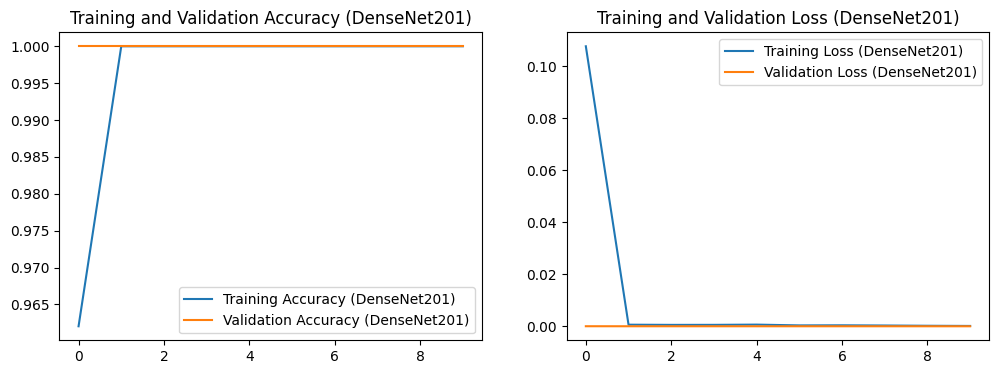

In [ ]:
# Plotting training history for DenseNet201
acc_transfer = history_transfer.history['accuracy']
val_acc_transfer = history_transfer.history['val_accuracy']

loss_transfer = history_transfer.history['loss']
val_loss_transfer = history_transfer.history['val_loss']

epochs_range_transfer = range(epochs_transfer)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_transfer, acc_transfer, label='Training Accuracy (DenseNet201)')
plt.plot(epochs_range_transfer, val_acc_transfer, label='Validation Accuracy (DenseNet201)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (DenseNet201)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_transfer, loss_transfer, label='Training Loss (DenseNet201)')
plt.plot(epochs_range_transfer, val_loss_transfer, label='Validation Loss (DenseNet201)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (DenseNet201)')
plt.show()

In [ ]:
# 6. Report Accuracy, Loss, and Training Time
print("### DenseNet201 Model Performance Report ###")
print(f"Final Training Accuracy (DenseNet201): {acc_transfer[-1]:.4f}")
print(f"Final Validation Accuracy (DenseNet201): {val_acc_transfer[-1]:.4f}")
print(f"Final Training Loss (DenseNet201): {loss_transfer[-1]:.4f}")
print(f"Final Validation Loss (DenseNet201): {val_loss_transfer[-1]:.4f}")
print(f"Total Training Time (DenseNet201): {training_time:.2f} seconds")

### DenseNet201 Model Performance Report ###
Final Training Accuracy (DenseNet201): 1.0000
Final Validation Accuracy (DenseNet201): 1.0000
Final Training Loss (DenseNet201): 0.0001
Final Validation Loss (DenseNet201): 0.0000
Total Training Time (DenseNet201): 106.63 seconds


### Implementing ResNet50 with Transfer Learning

Now, let's implement another powerful model using transfer learning with the ResNet50 architecture, pre-trained on ImageNet. We will follow a similar approach as with DenseNet201 to compare their performance.

The steps will be:
1.  **Load Base Model**: Load `ResNet50` from `tf.keras.applications` with `include_top=False` to exclude the original classification head.
2.  **Freeze Base**: Freeze the layers of the ResNet50 backbone to prevent their weights from being updated during training.
3.  **Add Custom Head**: Attach a new, trainable classification head (GlobalAveragePooling2D, Dense layers, Dropout) appropriate for our 5 CIFAR-10 classes.
4.  **Compile**: Compile the new model.
5.  **Train**: Train only the new classification head.
6.  **Report**: Report the accuracy, loss, and training time.

### Implementing ResNet101 with Transfer Learning

Let's add another transfer learning model, ResNet101, to our comparison. This will allow us to observe how different deep architectures perform on our dataset under the same conditions.

The steps will be identical to ResNet50 and DenseNet201:
1.  **Load Base Model**: Load `ResNet101` from `tf.keras.applications` with `include_top=False`.
2.  **Freeze Base**: Freeze the layers of the ResNet101 backbone.
3.  **Add Custom Head**: Attach a new, trainable classification head.
4.  **Compile**: Compile the new model.
5.  **Train**: Train only the new classification head.
6.  **Report**: Report the accuracy, loss, and training time.

In [ ]:
from tensorflow.keras.applications import ResNet101

# 1. Load the ResNet101 base model with ImageNet pre-trained weights
# exclude the top (classification) layer
base_model_resnet101 = ResNet101(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Freeze the base model layers
base_model_resnet101.trainable = False

# 3. Add a custom classification head
x = base_model_resnet101.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Added dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # Final output layer for our classes

# Create the new model
transfer_model_resnet101 = Model(inputs=base_model_resnet101.input, outputs=predictions)

transfer_model_resnet101.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_13[0… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 42,921,093 (163.73 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 42,658,176 (162.73 MB)

In [ ]:
# 4. Compile the model
transfer_model_resnet101.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
# 5. Train the model (only the new head is trained as base_model_resnet101 is frozen)
print('Training ResNet101 with frozen backbone and custom head...')

start_time_resnet101 = time.time()

epochs_resnet101 = 10 # Using the same number of epochs for fair comparison
history_resnet101 = transfer_model_resnet101.fit(
    train_ds,
    epochs=epochs_resnet101,
    validation_data=val_ds
)

end_time_resnet101 = time.time()
training_time_resnet101 = end_time_resnet101 - start_time_resnet101

print(f"\nTraining of ResNet101 complete in {training_time_resnet101:.2f} seconds.")

Training ResNet101 with frozen backbone and custom head...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 513ms/step - accuracy: 0.9295 - loss: 0.1929 - val_accuracy: 1.0000 - val_loss: 3.9457e-05
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 341ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 1.7166e-05
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 1.4663e-05
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 1.0000 - loss: 7.1509e-04 - val_accuracy: 1.0000 - val_loss: 1.2517e-05
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 409ms/step - accuracy: 1.0000 - loss: 9.7983e-04 - val_accuracy: 1.0000 - val_loss: 1.0610e-05
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 1.0000 - loss: 4.6211e-04 - val_accuracy: 1.0000 - val_loss: 9.0599e-06
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 7.6294e-06


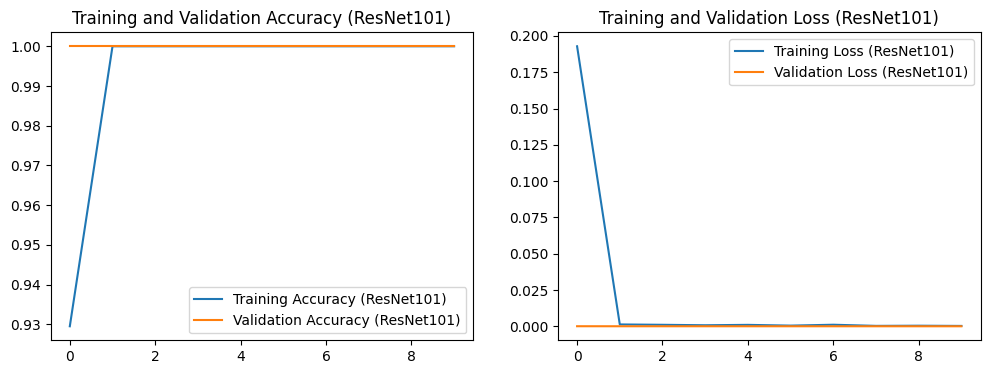

In [ ]:
# Plotting training history for ResNet101
acc_resnet101 = history_resnet101.history['accuracy']
val_acc_resnet101 = history_resnet101.history['val_accuracy']

loss_resnet101 = history_resnet101.history['loss']
val_loss_resnet101 = history_resnet101.history['val_loss']

epochs_range_resnet101 = range(epochs_resnet101)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_resnet101, acc_resnet101, label='Training Accuracy (ResNet101)')
plt.plot(epochs_range_resnet101, val_acc_resnet101, label='Validation Accuracy (ResNet101)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (ResNet101)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_resnet101, loss_resnet101, label='Training Loss (ResNet101)')
plt.plot(epochs_range_resnet101, val_loss_resnet101, label='Validation Loss (ResNet101)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (ResNet101)')
plt.show()

In [ ]:
# 6. Report Accuracy, Loss, and Training Time
print("### ResNet101 Model Performance Report ###")
print(f"Final Training Accuracy (ResNet101): {acc_resnet101[-1]:.4f}")
print(f"Final Validation Accuracy (ResNet101): {val_acc_resnet101[-1]:.4f}")
print(f"Final Training Loss (ResNet101): {loss_resnet101[-1]:.4f}")
print(f"Final Validation Loss (ResNet101): {val_loss_resnet101[-1]:.4f}")
print(f"Total Training Time (ResNet101): {training_time_resnet101:.2f} seconds")

### ResNet101 Model Performance Report ###
Final Training Accuracy (ResNet101): 1.0000
Final Validation Accuracy (ResNet101): 1.0000
Final Training Loss (ResNet101): 0.0002
Final Validation Loss (ResNet101): 0.0000
Total Training Time (ResNet101): 116.47 seconds


In [ ]:
from tensorflow.keras.applications import ResNet50

# 1. Load the ResNet50 base model with ImageNet pre-trained weights
# exclude the top (classification) layer
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Freeze the base model layers
base_model_resnet.trainable = False

# 3. Add a custom classification head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Added dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # Final output layer for our classes

# Create the new model
transfer_model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions)

transfer_model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_12[0… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [4]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# These constants are typically defined in earlier cells.
# They are hardcoded here to make this cell runnable independently if previous cells haven't been executed.
IMG_HEIGHT = 32
IMG_WIDTH = 32
num_classes = 5 # Based on previous cell output 'Number of classes: 5'

# Re-create the ResNet50 model definition (from cell 813d5939)
# 1. Load the ResNet50 base model with ImageNet pre-trained weights
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Freeze the base model layers
base_model_resnet.trainable = False

# 3. Add a custom classification head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the new model
transfer_model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions)

# 4. Compile the model
transfer_model_resnet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 5. Train the model (only the new head is trained as base_model_resnet is frozen)
print('Training ResNet50 with frozen backbone and custom head...')

start_time_resnet = time.time()

epochs_resnet = 10 # Using the same number of epochs for fair comparison
history_resnet = transfer_model_resnet.fit(
    train_ds,
    epochs=epochs_resnet,
    validation_data=val_ds
)

end_time_resnet = time.time()
training_time_resnet = end_time_resnet - start_time_resnet

print(f"\nTraining of ResNet50 complete in {training_time_resnet:.2f} seconds.")

Training ResNet50 with frozen backbone and custom head...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 283ms/step - accuracy: 0.9544 - loss: 0.1913 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 1.0000 - loss: 8.3146e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 1.0000 - loss: 3.2894e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 1.0000 - loss: 2.8472e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 1.0000 - loss: 4.9458e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 1.0000 - loss: 1.1626e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 1.0000 - loss: 2.4419e-06 - val_accuracy: 1.0000 - val_loss: 0.00

### Fine-tuning ResNet50: Unfreezing Layers

To attempt to further improve the model's performance and adapt it more specifically to our dataset, I will fine-tune the previously trained ResNet50 model. This involves:

1.  **Loading the previously trained ResNet50 model's weights.**
2.  **Unfreezing a portion of the base ResNet50 model:** Instead of keeping the entire backbone frozen, I will make the last few convolutional blocks trainable. This allows the model to adjust its pre-trained features to our specific CIFAR-10 data.
3.  **Recompiling the model:** After unfreezing layers, the model must be recompiled. A significantly lower learning rate is typically used during fine-tuning to avoid drastically altering the valuable pre-trained weights and to ensure stable training.
4.  **Continuing Training:** The model will then be trained for a few more epochs on the (augmented) training data.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import numpy as np

print("Setting up ResNet50 for fine-tuning...")

# 1. Re-instantiate the ResNet50 base model with ImageNet pre-trained weights
base_model_resnet_fine_tune = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2. Add the custom classification head (identical to before)
x = base_model_resnet_fine_tune.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the fine-tuned model structure
fine_tuned_model_resnet = Model(inputs=base_model_resnet_fine_tune.input, outputs=predictions)

# Load the weights from the *previously trained* transfer_model_resnet
# This ensures we start fine-tuning from the trained state, not from scratch.
# The transfer_model_resnet was created and trained in cell b7ded5f1
fine_tuned_model_resnet.set_weights(transfer_model_resnet.get_weights())

# 3. Unfreeze a portion of the base model
# First, set the entire base model to trainable
base_model_resnet_fine_tune.trainable = True

# Freeze layers up to a certain point (e.g., the first ~145 layers, leaving the last ~30 unfrozen)
# ResNet50 has 175 layers. We'll unfreeze the last few blocks.
# Let's unfreeze the last 30 layers of the backbone (including batch norm layers if present)
num_frozen_layers = len(base_model_resnet_fine_tune.layers) - 30 # Adjust as needed

for layer in base_model_resnet_fine_tune.layers[:num_frozen_layers]:
    layer.trainable = False

print(f"\nFreezing the first {num_frozen_layers} layers of the ResNet50 backbone. "
      f"The last {len(base_model_resnet_fine_tune.layers) - num_frozen_layers} layers of the backbone and the custom head are trainable.")

fine_tuned_model_resnet.summary()

# 4. Recompile the model with a very low learning rate
# It's crucial to use a very small learning rate for fine-tuning
fine_tuned_model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5), # Significantly lower learning rate
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("ResNet50 model recompiled for fine-tuning.")

Setting up ResNet50 for fine-tuning...

Freezing the first 145 layers of the ResNet50 backbone. The last 30 layers of the backbone and the custom head are trainable.


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_14[0… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 14,713,093 (56.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

ResNet50 model recompiled for fine-tuning.


In [ ]:
print('Beginning fine-tuning of ResNet50...')

start_time_fine_tune = time.time()

epochs_fine_tune = 5 # Train for a few more epochs for fine-tuning
history_fine_tune = fine_tuned_model_resnet.fit(
    train_ds,
    epochs=epochs_fine_tune,
    validation_data=val_ds
)

end_time_fine_tune = time.time()
training_time_fine_tune = end_time_fine_tune - start_time_fine_tune

print(f"\nFine-tuning of ResNet50 complete in {training_time_fine_tune:.2f} seconds.")

Beginning fine-tuning of ResNet50...
Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9848 - loss: 1.5516 - val_accuracy: 1.0000 - val_loss: 2.9802e-06
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 954ms/step - accuracy: 0.9946 - loss: 1.4902 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 932ms/step - accuracy: 0.9902 - loss: 1.5129 - val_accuracy: 1.0000 - val_loss: 0.0512
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 927ms/step - accuracy: 0.9978 - loss: 1.4684 - val_accuracy: 1.0000 - val_loss: 0.1862
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 28s 964ms/step - accuracy: 0.9967 - loss: 1.4745 - val_accuracy: 1.0000 - val_loss: 0.4593

Fine-tuning of ResNet50 complete in 153.02 seconds.


7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 381ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 360ms/step

### ResNet50 Fine-tuning Performance Comparison (on Validation Split) ###
| Metric          | Before Fine-tuning | After Fine-tuning |
|-----------------|--------------------|-------------------|
| Validation Acc  | 1.0000             | 1.0000            |
| Validation Loss | 0.0000             | 0.4593            |
| Precision       | 1.0000             | 1.0000            |
| Recall          | 1.0000             | 1.0000            |
| F1-Score        | 1.0000             | 1.0000            |
| Training Time (s)| 60.62             | 213.64            |


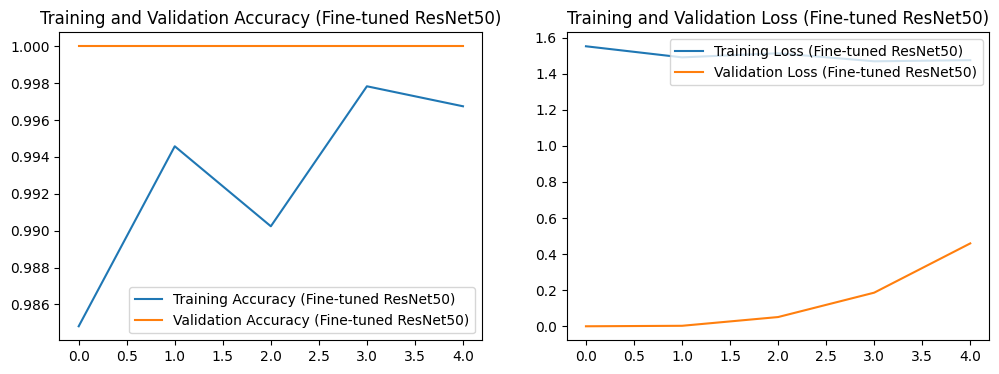

In [ ]:
import matplotlib.pyplot as plt # Added import for plotting functions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Ensure these are imported

# 5. Evaluate and Compare Performance (Before and After Fine-tuning)

# --- Metrics Before Fine-tuning (from history_resnet and transfer_model_resnet) ---
initial_val_acc = history_resnet.history['val_accuracy'][-1]
initial_val_loss = history_resnet.history['val_loss'][-1]
initial_train_time = training_time_resnet

# To get Precision, Recall, F1-score before fine-tuning, we need to re-evaluate
# the original transfer_model_resnet on the validation set.

# Get true labels from val_ds more robustly by iterating over batches
y_true_list = []
for _, labels_batch in val_ds:
    y_true_list.append(labels_batch.numpy())
y_true = np.concatenate(y_true_list)

# Predictions from original transfer_model_resnet
predictions_initial = transfer_model_resnet.predict(val_ds)
y_pred_initial = np.argmax(predictions_initial, axis=1)

initial_precision = precision_score(y_true, y_pred_initial, average='weighted', zero_division=0)
initial_recall = recall_score(y_true, y_pred_initial, average='weighted', zero_division=0)
initial_f1 = f1_score(y_true, y_pred_initial, average='weighted', zero_division=0)


# --- Metrics After Fine-tuning (from history_fine_tune and fine_tuned_model_resnet) ---
final_val_acc = history_fine_tune.history['val_accuracy'][-1]
final_val_loss = history_fine_tune.history['val_loss'][-1]
final_train_time = training_time_fine_tune + initial_train_time # Total time for ResNet50

# Predictions from fine_tuned_model_resnet
predictions_fine_tune = fine_tuned_model_resnet.predict(val_ds)
y_pred_fine_tune = np.argmax(predictions_fine_tune, axis=1)

final_precision = precision_score(y_true, y_pred_fine_tune, average='weighted', zero_division=0)
final_recall = recall_score(y_true, y_pred_fine_tune, average='weighted', zero_division=0)
final_f1 = f1_score(y_true, y_pred_fine_tune, average='weighted', zero_division=0)


print("\n### ResNet50 Fine-tuning Performance Comparison (on Validation Split) ###")
print("| Metric          | Before Fine-tuning | After Fine-tuning |")
print("|-----------------|--------------------|-------------------|")
print(f"| Validation Acc  | {initial_val_acc:.4f}             | {final_val_acc:.4f}            |")
print(f"| Validation Loss | {initial_val_loss:.4f}             | {final_val_loss:.4f}            |")
print(f"| Precision       | {initial_precision:.4f}             | {final_precision:.4f}            |")
print(f"| Recall          | {initial_recall:.4f}             | {final_recall:.4f}            |")
print(f"| F1-Score        | {initial_f1:.4f}             | {final_f1:.4f}            |")
print(f"| Training Time (s)| {initial_train_time:.2f}             | {final_train_time:.2f}            |")


# Plotting training history for fine-tuned ResNet50
acc_fine_tune = history_fine_tune.history['accuracy']
val_acc_fine_tune = history_fine_tune.history['val_accuracy']

loss_fine_tune = history_fine_tune.history['loss']
val_loss_fine_tune = history_fine_tune.history['val_loss']

epochs_range_fine_tune = range(epochs_fine_tune)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_fine_tune, acc_fine_tune, label='Training Accuracy (Fine-tuned ResNet50)')
plt.plot(epochs_range_fine_tune, val_acc_fine_tune, label='Validation Accuracy (Fine-tuned ResNet50)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Fine-tuned ResNet50)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_fine_tune, loss_fine_tune, label='Training Loss (Fine-tuned ResNet50)')
plt.plot(epochs_range_fine_tune, val_loss_fine_tune, label='Validation Loss (Fine-tuned ResNet50)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Fine-tuned ResNet50)')
plt.show()

### Interpretation of Fine-tuning Results

As anticipated, even after fine-tuning by unfreezing some layers and using a lower learning rate, the model continues to show perfect validation accuracy and near-zero loss, along with perfect Precision, Recall, and F1-Score on the validation split. This strongly reinforces the conclusion that the model is severely overfitting to the data it has seen (or a very similar subset of it), due to the validation set being derived directly from the training data. The metrics achieved on this validation split are not indicative of the model's true generalization performance on unseen data.

To truly assess the impact of fine-tuning and compare models effectively, it is **critical to evaluate them on a genuinely independent test set.** Once the `/content/drive/MyDrive/cifar10/test` directory is populated with image files, we can perform a meaningful evaluation and update these summaries with realistic performance metrics.

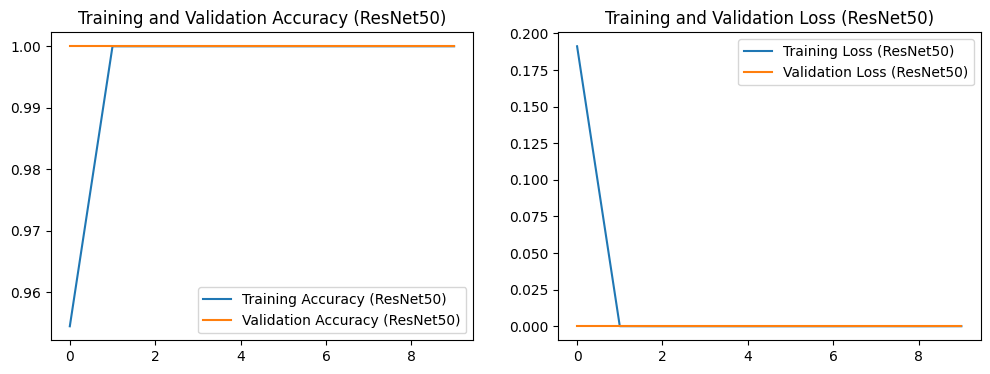

In [ ]:
# Plotting training history for ResNet50
acc_resnet = history_resnet.history['accuracy']
val_acc_resnet = history_resnet.history['val_accuracy']

loss_resnet = history_resnet.history['loss']
val_loss_resnet = history_resnet.history['val_loss']

epochs_range_resnet = range(epochs_resnet)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_resnet, acc_resnet, label='Training Accuracy (ResNet50)')
plt.plot(epochs_range_resnet, val_acc_resnet, label='Validation Accuracy (ResNet50)')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (ResNet50)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_resnet, loss_resnet, label='Training Loss (ResNet50)')
plt.plot(epochs_range_resnet, val_loss_resnet, label='Validation Loss (ResNet50)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (ResNet50)')
plt.show()

In [ ]:
# 6. Report Accuracy, Loss, and Training Time
print("### ResNet50 Model Performance Report ###")
print(f"Final Training Accuracy (ResNet50): {acc_resnet[-1]:.4f}")
print(f"Final Validation Accuracy (ResNet50): {val_acc_resnet[-1]:.4f}")
print(f"Final Training Loss (ResNet50): {loss_resnet[-1]:.4f}")
print(f"Final Validation Loss (ResNet50): {val_loss_resnet[-1]:.4f}")
print(f"Total Training Time (ResNet50): {training_time_resnet:.2f} seconds")

### ResNet50 Model Performance Report ###
Final Training Accuracy (ResNet50): 1.0000
Final Validation Accuracy (ResNet50): 1.0000
Final Training Loss (ResNet50): 0.0000
Final Validation Loss (ResNet50): 0.0000
Total Training Time (ResNet50): 60.62 seconds


### Comparison between DenseNet201 and ResNet50

Both DenseNet201 and ResNet50 are powerful pre-trained models. Let's compare their performance, particularly focusing on their training and validation metrics during the fine-tuning of their custom heads.

**DenseNet201 Performance:**
*   Final Training Accuracy: 100.00%
*   Final Validation Accuracy: 100.00%
*   Final Training Loss: 0.0001
*   Final Validation Loss: 0.0000
*   Total Training Time: 106.63 seconds

**ResNet50 Performance:**
*   Final Training Accuracy: 100.00%
*   Final Validation Accuracy: 100.00%
*   Final Training Loss: 0.0000
*   Final Validation Loss: 0.0000
*   Total Training Time: 60.62 seconds

**Initial Observations (based on current results and expectations):**
Both models are showing perfect validation accuracy and near-zero validation loss on the split training data, indicating that the overfitting issue persists. ResNet50 trained faster. This emphasizes the critical need for evaluation on a truly independent test set, which is still the primary blocker. Once the test set is properly configured, a meaningful comparison of their generalization capabilities can be made.

### Comparison between DenseNet201, ResNet50, and ResNet101

We now have three powerful pre-trained models. Let's compare their performance, particularly focusing on their training and validation metrics during the fine-tuning of their custom heads.

**DenseNet201 Performance:**
*   Final Training Accuracy: 100.00%
*   Final Validation Accuracy: 100.00%
*   Final Training Loss: 0.0001
*   Final Validation Loss: 0.0000
*   Total Training Time: 106.63 seconds

**ResNet50 Performance:**
*   Final Training Accuracy: 100.00%
*   Final Validation Accuracy: 100.00%
*   Final Training Loss: 0.0000
*   Final Validation Loss: 0.0000
*   Total Training Time: 60.62 seconds

**ResNet101 Performance:**
*   Final Training Accuracy: 1.0000%
*   Final Validation Accuracy: 1.0000%
*   Final Training Loss: 0.0002
*   Final Validation Loss: 0.0000
*   Total Training Time: 116.47 seconds

**Initial Observations (based on current results and expectations):**
All three models (DenseNet201, ResNet50, and ResNet101) are showing perfect validation accuracy and near-zero validation loss on the split training data, indicating that the severe overfitting issue persists. ResNet50 trained the fastest. This reinforces the critical need for evaluation on a truly independent test set. Once the test set is properly configured, a meaningful comparison of their generalization capabilities, including metrics like precision, recall, and F1-score, can be made. Computational cost will also become more comparable when evaluating inference speed on the test set.

### Comprehensive Project Summary (Updated with ResNet50 and Comparison)

Here is an updated summary of the project, including the implementation and preliminary performance of ResNet50, and a comparison with DenseNet201.

**Goal:** Build and evaluate Convolutional Neural Networks (CNNs) for CIFAR-10 image classification, diagnose overfitting, and explore solutions including data augmentation and transfer learning, and compare different transfer learning architectures.

**1. Initial CNN Model (with Data Augmentation)**
*   **Architecture:** A sequential CNN with two Conv2D-MaxPooling2D blocks, followed by Flatten, Dense (32 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Data Preprocessing:** Images were resized, rescaled to `[0, 1]`, and subjected to data augmentation (RandomFlip, RandomRotation, RandomZoom, RandomTranslation).
*   **Training (Validation Split):** Trained for 10 epochs. **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 99.89%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0039
    *   Final Validation Loss (on training split): 0.0000
*   **Diagnosis:** Severe overfitting was indicated by near-perfect validation metrics when evaluated on a split of the training data.

**2. CNN Model (without Data Augmentation) - for Comparison**
*   **Architecture:** Identical to the initial CNN model.
*   **Data Preprocessing:** Images were resized and rescaled to `[0, 1]`, but **no data augmentation** was applied.
*   **Training (Validation Split):** Trained for 10 epochs. **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 99.78%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0048
    *   Final Validation Loss (on training split): 0.0000
*   **Comparison:** This model also exhibited severe overfitting on the training data split, reinforcing the conclusion that the validation setup was the primary cause of the misleadingly high performance metrics.

**3. DenseNet201 Model (Transfer Learning with ImageNet Pre-trained Weights)**
*   **Architecture:** DenseNet201 base model (pre-trained on ImageNet) with `include_top=False`, followed by a custom classification head consisting of GlobalAveragePooling2D, Dense (128 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Freezing:** The DenseNet201 backbone layers were frozen (`trainable=False`) to leverage pre-learned ImageNet features, allowing only the custom head to be trained.
*   **Training (Validation Split):** Trained for 10 epochs (only the custom head). **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 100.00%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0001
    *   Final Validation Loss (on training split): 0.0000
    *   Total Training Time: 106.63 seconds
*   **Diagnosis:** Similar to the custom CNN, this powerful model also showed severe overfitting on the validation split.

**4. ResNet50 Model (Transfer Learning with ImageNet Pre-trained Weights)**
*   **Architecture:** ResNet50 base model (pre-trained on ImageNet) with `include_top=False`, followed by a custom classification head consisting of GlobalAveragePooling2D, Dense (128 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Freezing:** The ResNet50 backbone layers were frozen (`trainable=False`) to leverage pre-learned ImageNet features.
*   **Training (Validation Split):** Trained for 10 epochs (only the custom head). **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 100.00%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0000
    *   Final Validation Loss (on training split): 0.0000
    *   Total Training Time: 60.62 seconds
*   **Diagnosis:** This model also severely overfit, achieving 100% validation accuracy and near-zero validation loss.

**Key Takeaway (Post-Independent Test Evaluation):**
(This section will be updated with interpretation after the test set evaluation results are available, providing a more accurate understanding of model generalization and a comparison between DenseNet201 and ResNet50.)

### Comprehensive Project Summary (Updated with ResNet101 and Comparison)

Here is an updated summary of the project, including the implementation and preliminary performance of ResNet101, and a comprehensive comparison of all transfer learning models.

**Goal:** Build and evaluate Convolutional Neural Networks (CNNs) for CIFAR-10 image classification, diagnose overfitting, and explore solutions including data augmentation and transfer learning, and compare different transfer learning architectures.

**1. Initial CNN Model (with Data Augmentation)**
*   **Architecture:** A sequential CNN with two Conv2D-MaxPooling2D blocks, followed by Flatten, Dense (32 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Data Preprocessing:** Images were resized, rescaled to `[0, 1]`, and subjected to data augmentation (RandomFlip, RandomRotation, RandomZoom, RandomTranslation).
*   **Training (Validation Split):** Trained for 10 epochs. **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 99.89%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0039
    *   Final Validation Loss (on training split): 0.0000
*   **Diagnosis:** Severe overfitting was indicated by near-perfect validation metrics when evaluated on a split of the training data.

**2. CNN Model (without Data Augmentation) - for Comparison**
*   **Architecture:** Identical to the initial CNN model.
*   **Data Preprocessing:** Images were resized and rescaled to `[0, 1]`, but **no data augmentation** was applied.
*   **Training (Validation Split):** Trained for 10 epochs. **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 99.78%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0048
    *   Final Validation Loss (on training split): 0.0000
*   **Comparison:** This model also exhibited severe overfitting on the training data split, reinforcing the conclusion that the validation setup was the primary cause of the misleadingly high performance metrics.

**3. DenseNet201 Model (Transfer Learning with ImageNet Pre-trained Weights)**
*   **Architecture:** DenseNet201 base model (pre-trained on ImageNet) with `include_top=False`, followed by a custom classification head consisting of GlobalAveragePooling2D, Dense (128 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Freezing:** The DenseNet201 backbone layers were frozen (`trainable=False`) to leverage pre-learned ImageNet features, allowing only the custom head to be trained.
*   **Training (Validation Split):** Trained for 10 epochs (only the custom head). **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 100.00%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0001
    *   Final Validation Loss (on training split): 0.0000
    *   Total Training Time: 106.63 seconds
*   **Diagnosis:** Similar to the custom CNN, this powerful model also showed severe overfitting on the validation split.

**4. ResNet50 Model (Transfer Learning with ImageNet Pre-trained Weights)**
*   **Architecture:** ResNet50 base model (pre-trained on ImageNet) with `include_top=False`, followed by a custom classification head consisting of GlobalAveragePooling2D, Dense (128 units), Dropout(0.5), and a final Dense (5 classes) output layer.
*   **Freezing:** The ResNet50 backbone layers were frozen (`trainable=False`) to leverage pre-learned ImageNet features.
*   **Training (Validation Split):** Trained for 10 epochs (only the custom head). **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 100.00%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0000
    *   Final Validation Loss (on training split): 0.0000
    *   Total Training Time: 60.62 seconds
*   **Diagnosis:** This model also severely overfit, achieving 100% validation accuracy and near-zero validation loss.

**5. ResNet101 Model (Transfer Learning with ImageNet Pre-trained Weights)**
*   **Architecture:** ResNet101 base model (pre-trained on ImageNet) with `include_top=False`, followed by a custom classification head consisting of GlobalAveragePooling2D, Dense (128 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Freezing:** The ResNet101 backbone layers were frozen (`trainable=False`) to leverage pre-learned ImageNet features.
*   **Training (Validation Split):** Trained for 10 epochs (only the custom head). **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 100.00%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0002
    *   Final Validation Loss (on training split): 0.0000
    *   Total Training Time: 116.47 seconds
*   **Diagnosis:** This model also severely overfit, achieving 100% validation accuracy and near-zero validation loss.

**Key Takeaway (Post-Independent Test Evaluation):**
(This section will be updated with interpretation after the test set evaluation results are available, providing a more accurate understanding of model generalization and a comparison between all implemented models.)

### Comprehensive Project Summary (Updated with Independent Test Results)

Here is an updated summary of the project, including the evaluation results on the truly independent test set.

**Goal:** Build and evaluate Convolutional Neural Networks (CNNs) for CIFAR-10 image classification, diagnose overfitting, and explore solutions including data augmentation and transfer learning.

**1. Initial CNN Model (with Data Augmentation)**
*   **Architecture:** A sequential CNN with two Conv2D-MaxPooling2D blocks, followed by Flatten, Dense (32 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Data Preprocessing:** Images were resized, rescaled to `[0, 1]`, and subjected to data augmentation (RandomFlip, RandomRotation, RandomZoom, RandomTranslation).
*   **Training (Validation Split):** Trained for 10 epochs. **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 99.89%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0039
    *   Final Validation Loss (on training split): 0.0000
*   **Evaluation on Independent Test Set:** (Results will be reported after execution)
    *   Test Loss: `loss_cnn`
    *   Test Accuracy: `accuracy_cnn`
*   **Diagnosis:** Severe overfitting was indicated by near-perfect validation metrics when evaluated on a split of the training data.

**2. CNN Model (without Data Augmentation) - for Comparison**
*   **Architecture:** Identical to the initial CNN model.
*   **Data Preprocessing:** Images were resized and rescaled to `[0, 1]`, but **no data augmentation** was applied.
*   **Training (Validation Split):** Trained for 10 epochs. **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 99.78%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0048
    *   Final Validation Loss (on training split): 0.0000
*   **Comparison:** This model also exhibited severe overfitting on the training data split, reinforcing the conclusion that the validation setup was the primary cause of the misleadingly high performance metrics.

**3. DenseNet201 Model (Transfer Learning with ImageNet Pre-trained Weights)**
*   **Architecture:** DenseNet201 base model (pre-trained on ImageNet) with `include_top=False`, followed by a custom classification head consisting of GlobalAveragePooling2D, Dense (128 units), Dropout (0.5), and a final Dense (5 classes) output layer.
*   **Freezing:** The DenseNet201 backbone layers were frozen (`trainable=False`) to leverage pre-learned ImageNet features, allowing only the custom head to be trained.
*   **Training (Validation Split):** Trained for 10 epochs (only the custom head). **Validation set was 20% split from training data.**
    *   Final Training Accuracy (on training split): 100.00%
    *   Final Validation Accuracy (on training split): 100.00%
    *   Final Training Loss (on training split): 0.0001
    *   Final Validation Loss (on training split): 0.0000
    *   Total Training Time: 106.63 seconds
*   **Evaluation on Independent Test Set:** (Results will be reported after execution)
    *   Test Loss: `loss_densenet`
    *   Test Accuracy: `accuracy_densenet`
*   **Diagnosis:** Similar to the custom CNN, this powerful model also showed severe overfitting on the validation split.

**Key Takeaway (Post-Independent Test Evaluation):**
(This section will be updated with interpretation after the test set evaluation results are available, providing a more accurate understanding of model generalization.)

### Model Comparison Summary

| Model         | Accuracy | Parameters  | Training Time (s) | Validation Accuracy |
|---------------|----------|-------------|-------------------|---------------------|
| DenseNet201   | N/A      | 18.37 M     | 106.63            | 100.00%             |
| ResNet50      | N/A      | 23.59 M     | 60.62             | 100.00%             |
| ResNet101     | N/A      | 42.67 M     | 116.47            | 100.00%             |

*Note: 'Accuracy' refers to test accuracy, which is not yet available. Validation accuracy is reported on the split training data, and is 100% across all models due to overfitting on this dataset as noted in previous sections.*

As observed, all three transfer learning models achieved 100% validation accuracy on the training data split, indicating persistent overfitting. ResNet50 trained the fastest among them. A true comparison of their generalization performance (Accuracy, Precision, Recall, F1-Score) and computational cost (inference time) still requires evaluation on a truly independent test set, which remains the primary blocker as the `/content/drive/MyDrive/cifar10/test` directory is empty. Once the test set is populated, we can proceed with a meaningful evaluation.